### **youtube-sinhala-dataset**

## 0. Setup

All external, non-stdlib packages this notebook needs, installed up front so every later
cell can assume they're present rather than failing partway through a long run.

In [1]:
!pip install -q pandas numpy soundfile tqdm matplotlib torch torchaudio


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip


## 1. Load the dataset

The YouTube corpus ships as pre-made train/validation/test Parquet shards (train split across two files). We read all of them and concatenate into one DataFrame, tagging each row with a `split` column so the original assignment survives the merge. Unlike the other corpora, this one already carries rich per-clip metadata: `video_id`, `uploader`, `domain`, `speaker_gender`, `has_noise`, `is_code_mixed`, and a precomputed `duration`.

**Expect:** 4,037 rows x 9 columns.

In [2]:
import pandas as pd
from pathlib import Path

base = Path("youtubeData/data")

files = {
    "train":      sorted(base.glob("train-*-of-*.parquet")),
    "validation": sorted(base.glob("validation-*-of-*.parquet")),
    "test":       sorted(base.glob("test-*-of-*.parquet")),
}

df = pd.concat(
    [pd.read_parquet(f).assign(split=name) for name, fs in files.items() for f in fs],
    ignore_index=True,
)

print(df.shape)
print(df["split"].value_counts())

(4037, 10)
split
train         3229
test           405
validation     403
Name: count, dtype: int64


### Inspect the raw structure

A quick look at the first rows to confirm what each column actually contains before we trust it.

In [3]:
df.head(5)

,audio,text,duration,video_id,uploader,domain,speaker_gender,has_noise,is_code_mixed,split
0,"{'bytes': b'RIFF""(\x05\x00WAVEfmt \x10\x00\x00...",ඔහුට අවශ්‍ය වෙනවා චිත්‍ර කලාව පිළිබඳ වැඩිදුර ඉ...,10.56,J19XUE9VFxs,Vidusara Online,history_and_cultural,male,False,False,train
1,{'bytes': b'RIFFb\xea\x02\x00WAVEfmt \x10\x00\...,ඔබ කතාකරපු දේවල් ඔබ පැමිණි අවස්ථා ගණන ඔබ තෝරගත...,5.97,rvsczE01LPQ,Sri Lanka Rupavahini,politics_and_government,male,False,False,train
2,"{'bytes': b'RIFF""8\x04\x00WAVEfmt \x10\x00\x00...","හරි, සුනිල්ගේ වැඩේ ඉවර වෙනකල් මූව අරන් පලයන් හ...",8.64,k9NE4Ib36k0,Koombiyo,entertainment,male,False,False,train
3,"{'bytes': b'RIFF""H\x03\x00WAVEfmt \x10\x00\x00...",ඒ බුදුරජාණන් වහන්සේත් බණ කියනවා. සත්තු මරන්න එ...,6.72,kcKX6m_MlyM,Shakya අරණ,religion,male,False,False,train
4,"{'bytes': b'RIFF""V\x04\x00WAVEfmt \x10\x00\x00...",ඒ ඔබට අවශ්‍ය පරීක්ෂණ වලට යොමුවෙන්න ඕන. ඔය විදි...,8.88,QX0Pg7E7Z20,Arogya - ආරෝග්‍යා,health,male,False,False,train


## 2. Basic inventory

Total utterances, missing transcripts, and (where available) speaker/metadata breakdowns —
the counts that frame everything downstream.

In [4]:
print("Total utterances:", len(df))
print("missing transcripts:", df["text"].isnull().sum())


Total utterances: 4037
missing transcripts: 0


### Metadata breakdown

This corpus carries fields none of the other datasets have: `domain` (content category), `uploader`,
`speaker_gender`, and two pre-flagged quality signals — `has_noise` and `is_code_mixed`. Worth
checking upfront since they can drive stratified sampling or targeted filtering later.

In [5]:
print(df["domain"].value_counts())
print()
print(df["speaker_gender"].value_counts())
print()
print("has_noise:", df["has_noise"].value_counts().to_dict())
print("is_code_mixed:", df["is_code_mixed"].value_counts().to_dict())
print()
print("Unique uploaders:", df["uploader"].nunique())
print("Unique videos:", df["video_id"].nunique())

domain
business_and_finance        1128
education                    678
technology_and_computing     656
entertainment                317
religion                     273
politics_and_government      194
history_and_cultural         176
science                      103
law_and_justice               99
food_and_drink                95
news_and_current_affairs      84
health                        79
work_and_careers              68
sports                        55
media_marketing               32
Name: count, dtype: int64

speaker_gender
male                 3147
female                883
cannot_recognized       7
Name: count, dtype: int64

has_noise: {False: 3899, True: 138}
is_code_mixed: {True: 2180, False: 1857}

Unique uploaders: 34
Unique videos: 110


### Transcript length distribution

Character counts per transcript. On its own this is a sanity check, but it becomes the numerator
of the chars-per-second ratio further down, our main misalignment detector.

A minimum near zero means empty/stub transcripts; a very large maximum matters because Whisper's
decoder caps at 448 tokens, and Sinhala tokenizes inefficiently under Whisper's BPE.

In [6]:
df["text_len"] = df["text"].str.len()
df["text_len"].describe()

count    4037.000000
mean      100.159524
std        49.836092
min        14.000000
25%        68.000000
50%        89.000000
75%       120.000000
max       416.000000
Name: text_len, dtype: float64

## 3. Duration extraction

`sf.info()` reads only the file header — sample rate, frame count, channels — so duration comes
essentially for free without decoding the full waveform.

`get_duration` handles both shapes the audio cell can take (a HuggingFace-style `{'bytes': ...}`
dict, or raw bytes) and returns `None` on failure rather than raising, so one corrupt file cannot
abort the pass over the whole dataset.

In [7]:
import io
import soundfile as sf

def get_duration(audio):
    if audio is None:
        return None
    raw = audio['bytes'] if isinstance(audio, dict) else audio
    if raw is None:
        return None
    try:
        info = sf.info(io.BytesIO(raw))
        return info.duration
    except Exception:
        return None

df["duration_check"] = df["audio"].apply(get_duration)

### Duration summary

Whisper's encoder always consumes a fixed 30-second window: shorter audio is zero-padded, and
**anything longer is silently truncated while the full transcript is kept as the label** — a
direct path to hallucination. The number that matters most here is the maximum.

In [8]:
df["duration_check"].describe()

count    4037.000000
mean        8.127450
std         2.526538
min         2.909937
25%         6.329937
50%         7.589937
75%         9.209938
max        24.840000
Name: duration_check, dtype: float64

### Listen to the longest clip

The single most informative clip to audition manually — if anything breaches the 30 s window or
carries a truncated transcript, it will be this one.

In [9]:
from IPython.display import Audio, display

row = df.loc[df["duration_check"].idxmax()]
raw = row["audio"]['bytes'] if isinstance(row["audio"], dict) else row["audio"]

display(Audio(data=raw))
print(row["duration_check"], "sec")
print(row["text"])

24.84 sec
එතකොට දැන් forth fifth year එක වෙනවා එතකොට ඔයා බලන්න ඕන  තව කොහොමද මේක diversify වෙන්න පුළුවන් කියලා එතකොට චූටි risk එකක් ගන්න පුළුවන් රවී ඔයාට ඒ කියන්නේ මොකක්ද දැන් emergency fund එකකුත් තියෙනවා right කතන්දරේ තියෙනවා හැබැයි මේ වෙද්දි රවී  ඔයා අත ගහන්න බෑ වාහනෙට ඒ කියන්නේ වාහනේ upgration එහෙකට හරි නැත්තං හිතන්නකෝ දැනට pick me එකක ගියපු ඔයා එක ගියපු ඔයා දැනට මොකක් හරි uber එකේ ගියපු එයා


## **Transcript-audio alignment issues**

### Characters per second

`len(text) / duration` should cluster tightly for genuine speech. Rows outside the band are
almost always broken pairs rather than unusual speakers — too high means more text than the audio
could plausibly contain, too low means a truncated transcript or a mostly-silent/noisy clip.

The 2–30 thresholds are calibrated to Sinhala script; read the printed distribution and cut in the
tails rather than trusting numbers imported from another dataset.

In [10]:
import numpy as np
from IPython.display import Audio, display

df["chars_per_sec"] = df["text"].str.len() / df["duration_check"]
print(df["chars_per_sec"].describe())

suspicious = df[(df["chars_per_sec"] > 30) | (df["chars_per_sec"] < 2)]
print(f"Suspicious rows: {len(suspicious)} of {len(df)}")

def play(idx):
    row = df.loc[idx]
    raw = row['audio']['bytes'] if isinstance(row['audio'], dict) else row['audio']
    print(f"[{idx}] {row['duration_check']:.2f}s | {row['chars_per_sec']:.1f} chars/sec")
    print(row['text'])
    display(Audio(data=raw))

if len(suspicious):
    play(suspicious["chars_per_sec"].idxmax())

count    4037.000000
mean       12.072624
std         3.437622
min         1.486989
25%         9.753549
50%        11.610577
75%        14.179988
max        26.465927
Name: chars_per_sec, dtype: float64
Suspicious rows: 4 of 4037
[2250] 7.62s | 1.8 chars/sec
අද කෝවිලේ පූජා


## **Empty or garbage transcripts**

### Empty and stub transcripts

An empty transcript paired with real speech is the worst training example possible — it teaches
the model that speech maps to nothing. Stub transcripts under a few characters are the milder
version and worth auditioning before deciding fix vs. drop.

In [11]:
text = df["text"].fillna("").str.strip()

empty_text = df[text == ""]
very_short_text = df[(text != "") & (text.str.len() < 3)]

print(f"Empty/whitespace: {len(empty_text)}")
print(f"Very short (<3 chars): {len(very_short_text)}")

Empty/whitespace: 0
Very short (<3 chars): 0


In [12]:
# Placeholder labels the source dataset uses for clips it couldn't transcribe —
# these read as real text (non-empty) but carry no usable transcript.
PLACEHOLDER_PATTERNS = [
    "audio not suitable for transcription",
]

text_lower = df["text"].fillna("").str.strip().str.lower()
not_found = df[text_lower.isin(PLACEHOLDER_PATTERNS)]

print(f"Rows with a 'not suitable for transcription' placeholder: {len(not_found)}")
display(not_found[["split", "duration", "text"]])

Rows with a 'not suitable for transcription' placeholder: 3


,split,duration,text
258,train,24.21,Audio not suitable for transcription
1807,train,15.72,Audio not suitable for transcription
3555,validation,23.21,Audio not suitable for transcription


## **Duplicates**

### Duplicate transcripts

Duplicates over-weight whatever they contain within a split, and — far worse — leak the answer
if the same transcript appears in both train and test.

In [13]:
text = df["text"].fillna("").str.strip()

dup_mask = text.duplicated(keep=False) & (text != "")
print(f"Rows with a duplicated transcript: {dup_mask.sum()}")

dup_groups = df[dup_mask].groupby(text[dup_mask]).groups
print(f"Distinct duplicated transcripts: {len(dup_groups)}")

for t, idxs in list(dup_groups.items())[:3]:
    print(f"\n--- {t[:120]}")
    print(df.loc[idxs, ["duration_check", "chars_per_sec"]].to_string())

Rows with a duplicated transcript: 5
Distinct duplicated transcripts: 2

--- 1972 දක්වා ක්‍රියාත්මක වුණු සෝල්බරි ආණ්ඩුක්‍රම යටතේ
      duration_check  chars_per_sec
1497            5.91       8.629442
2095            6.36       8.018868

--- Audio not suitable for transcription
      duration_check  chars_per_sec
258            24.21       1.486989
1807           15.72       2.290076
3555           23.21       1.551056


In [14]:
from IPython.display import Audio, display

def get_bytes(cell):
    if isinstance(cell, dict):
        return cell["bytes"]
    if isinstance(cell, (bytes, bytearray, np.ndarray)):
        return bytes(cell)
    raise TypeError(type(cell))

N_GROUPS = 5  # how many duplicate-transcript groups to audition

for t, idxs in list(dup_groups.items())[:N_GROUPS]:
    print(f"\n=== Transcript: {t}")
    print(f"File indices sharing this transcript: {list(idxs)}\n")
    for idx in idxs:
        row = df.loc[idx]
        print(f"[{idx}] {row['duration_check']:.2f}s | {row['chars_per_sec']:.1f} chars/sec")
        display(Audio(data=get_bytes(row["audio"])))


=== Transcript: 1972 දක්වා ක්‍රියාත්මක වුණු සෝල්බරි ආණ්ඩුක්‍රම යටතේ
File indices sharing this transcript: [1497, 2095]

[1497] 5.91s | 8.6 chars/sec


[2095] 6.36s | 8.0 chars/sec



=== Transcript: Audio not suitable for transcription
File indices sharing this transcript: [258, 1807, 3555]

[258] 24.21s | 1.5 chars/sec


[1807] 15.72s | 2.3 chars/sec


[3555] 23.21s | 1.6 chars/sec


## **Non-target-language contamination**

### Language contamination

Fraction of each transcript's non-whitespace characters that fall inside the Sinhala Unicode
block (U+0D80–U+0DFF). Some Latin script (code-switching) is expected and fine; `sinhala_ratio == 0`
is the degenerate case worth flagging — a wrong-language row or placeholder rather than real
code-switching.

In [15]:
import re

SINHALA = re.compile(r'[\u0D80-\u0DFF]')
text = df["text"].fillna("")

df["sinhala_ratio"] = text.apply(
    lambda t: len(SINHALA.findall(t)) / max(len(re.sub(r'\s', '', t)), 1)
)

no_sinhala = df[df["sinhala_ratio"] == 0]
mostly_latin = df[(df["sinhala_ratio"] > 0) & (df["sinhala_ratio"] < 0.3)]

print(f"No Sinhala at all: {len(no_sinhala)}")
print(f"Mostly non-Sinhala (<30%): {len(mostly_latin)}")
print(df.loc[no_sinhala.index, ["duration_check", "text"]].head(10).to_string())

No Sinhala at all: 10
Mostly non-Sinhala (<30%): 24
      duration_check                                                                               text
258        24.210000                                               Audio not suitable for transcription
771         6.959937                                        media politics geography history logic econ
1085        7.829937          so you get to know that I dont't always you know have the easy going life
1580        6.749937                                Happy Birthday To you. I don't deserve this. What's
1807       15.720000                                               Audio not suitable for transcription
1869        6.089937                       something related to food if it's cosmetics if it's whatever
2051        5.549938                                 hi good morning welcome back to my youtube channel
2345        7.919937                 Perfect. I finally got the perfect coffee. I ordered a Cafela tea.
3480        

## 4. Audio header probe

A second pass over the audio, recording sample rate, channel count, subtype, container format,
and byte size. Errors are captured per-row into an `error` column instead of raised, so one
corrupt file doesn't abort the whole pass.

In [16]:
from tqdm.auto import tqdm

def get_bytes(cell):
    if isinstance(cell, dict):
        return cell["bytes"]
    if isinstance(cell, (bytes, bytearray, np.ndarray)):
        return bytes(cell)
    raise TypeError(type(cell))

rows = []
for i, cell in tqdm(df["audio"].items(), total=len(df), desc="headers"):
    r = {"idx": i, "error": None}
    try:
        b = get_bytes(cell)
        r["n_bytes"] = len(b)
        info = sf.info(io.BytesIO(b))
        r.update(sr=info.samplerate, channels=info.channels, subtype=info.subtype,
                 fmt=info.format, frames=info.frames,
                 duration=info.frames / info.samplerate)
    except Exception as e:
        r["error"] = f"{type(e).__name__}: {e}"
    rows.append(r)

meta = pd.DataFrame(rows).set_index("idx")
meta = df[["split", "text"]].join(meta)
print("unreadable:", meta.error.notna().sum())
display(meta[meta.error.notna()].head())
meta.head()

headers:   0%|          | 0/4037 [00:00<?, ?it/s]

unreadable: 0


,split,text,error,n_bytes,sr,channels,subtype,fmt,frames,duration


,split,text,error,n_bytes,sr,channels,subtype,fmt,frames,duration
0,train,ඔහුට අවශ්‍ය වෙනවා චිත්‍ර කලාව පිළිබඳ වැඩිදුර ඉ...,None,337962,16000,1,PCM_16,WAV,168959,10.559938
1,train,ඔබ කතාකරපු දේවල් ඔබ පැමිණි අවස්ථා ගණන ඔබ තෝරගත...,None,191082,16000,1,PCM_16,WAV,95519,5.969938
2,train,"හරි, සුනිල්ගේ වැඩේ ඉවර වෙනකල් මූව අරන් පලයන් හ...",None,276522,16000,1,PCM_16,WAV,138239,8.639938
3,train,ඒ බුදුරජාණන් වහන්සේත් බණ කියනවා. සත්තු මරන්න එ...,None,215082,16000,1,PCM_16,WAV,107519,6.719938
4,train,ඒ ඔබට අවශ්‍ය පරීක්ෂණ වලට යොමුවෙන්න ඕන. ඔය විදි...,None,284202,16000,1,PCM_16,WAV,142079,8.879938


### Duration statistics, overall and per split

Total hours is the number that should shape the training recipe. The `over_30s` / `over_29s` /
`under_0.5s` columns are the actionable ones: anything over 30 s would be truncated against a full
transcript, and sub-0.5 s clips are usually fragments.

In [17]:
ok = meta[meta.error.isna()].copy()

overall = pd.Series({
    "n_clips": len(ok),
    "hours":   ok.duration.sum()/3600,
    "min_s":   ok.duration.min(),
    "p50_s":   ok.duration.quantile(.50),
    "p95_s":   ok.duration.quantile(.95),
    "p99_s":   ok.duration.quantile(.99),
    "max_s":   ok.duration.max(),
    "mean_s":  ok.duration.mean(),
}).round(2)
display(overall.to_frame("youtube"))

per_split = ok.groupby("split").duration.agg(
    n_clips="size",
    hours=lambda s: s.sum()/3600,
    min_s="min",
    p50_s=lambda s: s.quantile(.50),
    p95_s=lambda s: s.quantile(.95),
    p99_s=lambda s: s.quantile(.99),
    max_s="max",
).round(2)
for lbl, m in [("over_30s", ok.duration > 30), ("over_29s", ok.duration > 29),
               ("under_0.5s", ok.duration < 0.5)]:
    per_split[lbl] = ok[m].groupby("split").size().reindex(per_split.index, fill_value=0)
display(per_split)

print(f"clips exceeding Whisper's 30 s window: {(ok.duration > 30).sum()}")

,youtube
n_clips,4037.00
hours,9.11
min_s,2.91
p50_s,7.59
p95_s,12.07
p99_s,18.63
max_s,24.84
mean_s,8.13


,n_clips,hours,min_s,p50_s,p95_s,p99_s,max_s,over_30s,over_29s,under_0.5s
split,,,,,,,,,,
test,405,0.93,2.91,7.68,12.40,19.68,24.07,0,0,0
train,3229,7.26,2.91,7.56,11.93,18.50,24.84,0,0,0
validation,403,0.92,4.11,7.68,12.18,17.83,23.21,0,0,0


clips exceeding Whisper's 30 s window: 0


### Format compliance

Whisper requires 16 kHz mono. Groups every distinct (sample rate, channels, subtype, format)
combination so any inconsistency shows up immediately. Sample rate below 16 kHz is the critical
row — it is not fixable, since upsampling cannot restore frequency content never captured.

In [18]:
display(ok.groupby(["sr", "channels", "subtype", "fmt"]).size()
          .rename("count").reset_index().sort_values("count", ascending=False))

print("not 16 kHz:", (ok.sr != 16000).sum(), "->", sorted(ok.sr.unique().tolist()))
print("not mono  :", (ok.channels != 1).sum())
print("subtypes  :", ok.subtype.value_counts().to_dict())

low = ok[ok.sr < 16000]
if len(low):
    print(f"\n\u26a0 {len(low)} clips below 16 kHz ({low.duration.sum()/3600:.2f} h) "
          "— band-limited; upsampling cannot recover this")

,sr,channels,subtype,fmt,count
0,16000,1,PCM_16,WAV,4037


not 16 kHz: 0 -> [16000]
not mono  : 0
subtypes  : {'PCM_16': 4037}


## 5. Level and silence analysis

The first pass that actually decodes the waveforms. `frame_rms` slices the signal into
overlapping 1024-sample windows (64 ms at 16 kHz) advancing 512 samples at a time, computing RMS
energy per window so we can locate *where* silence is, not just how loud the clip is overall.

| Metric | Meaning | Why it matters |
|---|---|---|
| `peak_dbfs` | loudest single sample | near 0 dBFS suggests clipping |
| `rms_dbfs` | average energy | overall loudness; big spreads mean inconsistent levels |
| `clip_frac` | fraction of samples at full scale | actual distortion, unrecoverable |
| `silence_frac` | fraction of frames below threshold | mostly-silent clips waste the encoder window |
| `lead_sil_s` | silence before first voiced frame | segmentation started too early |
| `trail_sil_s` | silence after last voiced frame | segmentation ended too late |

`SIL_DBFS = -45` is an *absolute* level, so a quietly recorded clip can register as mostly silent
even with continuous speech — which is exactly why the VAD cross-check in section 6 exists.

In [19]:
SIL_DBFS, FRAME, HOP = -45.0, 1024, 512

def frame_rms(x):
    if len(x) < FRAME:
        return np.array([np.sqrt(np.mean(x**2) + 1e-12)])
    n = 1 + (len(x) - FRAME)//HOP
    idx = np.arange(FRAME)[None, :] + HOP*np.arange(n)[:, None]
    return np.sqrt(np.mean(x[idx]**2, axis=1) + 1e-12)

def analyse(b):
    x, sr = sf.read(io.BytesIO(b), dtype="float32", always_2d=True)
    x = x.mean(axis=1)
    d = len(x)/sr
    voiced = 20*np.log10(frame_rms(x)) > SIL_DBFS
    hop_s = HOP/sr
    if voiced.any():
        lead  = np.argmax(voiced) * hop_s
        trail = max(0.0, d - (len(voiced)-1-np.argmax(voiced[::-1])) * hop_s)
    else:
        lead = trail = d
    to_db = lambda v: 20*np.log10(max(float(v), 1e-10))
    return dict(peak_dbfs=to_db(np.abs(x).max()),
                rms_dbfs=to_db(np.sqrt(np.mean(x**2))),
                clip_frac=float((np.abs(x) >= .999).mean()),
                silence_frac=float((~voiced).mean()),
                lead_sil_s=float(lead), trail_sil_s=float(trail))

recs = []
for i in tqdm(ok.index, desc="levels + silence"):
    try:
        recs.append({"idx": i, **analyse(get_bytes(df.at[i, "audio"]))})
    except Exception as e:
        recs.append({"idx": i, "err": str(e)})

lv = pd.DataFrame(recs).set_index("idx").join(ok[["split", "text", "duration"]])
lv.head()

levels + silence:   0%|          | 0/4037 [00:00<?, ?it/s]

,peak_dbfs,rms_dbfs,clip_frac,silence_frac,lead_sil_s,trail_sil_s,split,text,duration
idx,,,,,,,,,
0,-1.372355,-12.301350,0.0,0.198171,0.960,0.927938,train,ඔහුට අවශ්‍ය වෙනවා චිත්‍ර කලාව පිළිබඳ වැඩිදුර ඉ...,10.559938
1,-6.879150,-24.733369,0.0,0.237838,0.960,0.529937,train,ඔබ කතාකරපු දේවල් ඔබ පැමිණි අවස්ථා ගණන ඔබ තෝරගත...,5.969938
2,-6.954384,-31.801502,0.0,0.604478,1.536,1.151937,train,"හරි, සුනිල්ගේ වැඩේ ඉවර වෙනකල් මූව අරන් පලයන් හ...",8.639938
3,-1.213321,-21.401659,0.0,0.389423,0.960,0.959938,train,ඒ බුදුරජාණන් වහන්සේත් බණ කියනවා. සත්තු මරන්න එ...,6.719938
4,-1.415302,-19.750845,0.0,0.333333,0.960,0.911938,train,ඒ ඔබට අවශ්‍ය පරීක්ෂණ වලට යොමුවෙන්න ඕන. ඔය විදි...,8.879938


### Level report and flagging

`near_silent` catches recordings that essentially failed; `very_quiet` catches level outliers that
are still usable; `clipped` catches distortion; `mostly_silence` and the lead/trail flags catch bad
segment boundaries. `n_flags` sums the conditions per clip so the worst offenders sort to the top.

,rms_dbfs,peak_dbfs,clip_frac,silence_frac,lead_sil_s,trail_sil_s
count,4037.00,4037.00,4037.0,4037.00,4037.00,4037.00
mean,-23.43,-5.26,0.0,0.26,0.74,0.64
std,4.03,3.66,0.0,0.11,0.42,0.40
min,-43.92,-25.33,0.0,0.00,0.00,0.06
5%,-29.71,-11.97,0.0,0.10,0.00,0.07
25%,-25.48,-7.65,0.0,0.18,0.96,0.51
50%,-23.59,-4.61,0.0,0.26,0.96,0.75
75%,-21.62,-2.58,0.0,0.33,0.96,0.91
95%,-15.51,-0.24,0.0,0.44,0.99,1.02
max,-12.00,0.00,0.0,0.85,2.85,6.82


,rms_dbfs,peak_dbfs,clip_frac,silence_frac,lead_sil_s,trail_sil_s
split,,,,,,
test,-23.31,-4.35,0.0,0.25,0.96,0.62
train,-23.59,-4.63,0.0,0.26,0.96,0.77
validation,-23.77,-4.90,0.0,0.26,0.96,0.71


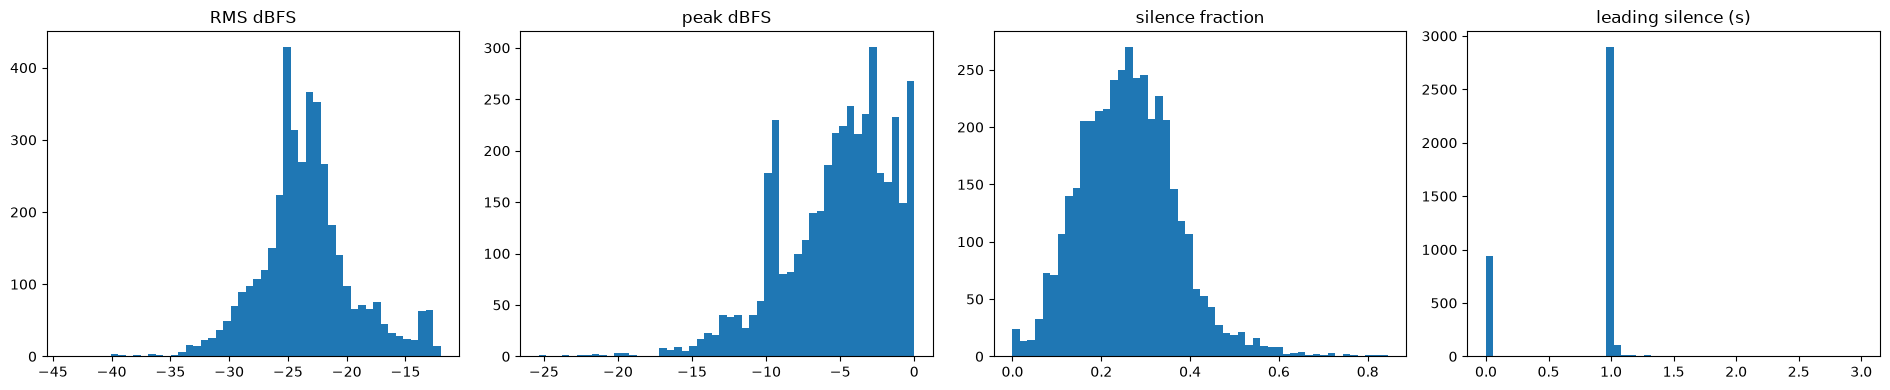

,n_clips
near_silent,0
very_quiet,8
clipped,0
mostly_silence,26
long_lead_sil,6
long_trail_sil,35


,near_silent,very_quiet,clipped,mostly_silence,long_lead_sil,long_trail_sil
split,,,,,,
test,0,2,0,5,0,7
train,0,5,0,18,5,26
validation,0,1,0,3,1,2


,split,duration,rms_dbfs,clip_frac,silence_frac,lead_sil_s,n_flags
idx,,,,,,,
1005,train,8.729938,-23.812553,0.0,0.845018,0.992,2
2,train,8.639938,-31.801502,0.0,0.604478,1.536,2
1566,train,6.329937,-32.568735,0.0,0.744898,0.992,2
3765,test,8.039938,-19.588033,0.0,0.644000,0.960,2
3685,test,6.719938,-20.276895,0.0,0.692308,0.960,2
3949,test,6.570000,-27.095469,0.0,0.769608,0.992,2
1846,train,9.569937,-21.034096,0.0,0.808725,0.960,2
2717,train,8.430000,-22.599315,0.0,0.606870,1.024,2
2895,train,9.450000,-30.883652,0.0,0.649660,0.960,2


In [20]:
import matplotlib.pyplot as plt

cols = ["rms_dbfs", "peak_dbfs", "clip_frac", "silence_frac", "lead_sil_s", "trail_sil_s"]
display(lv[cols].describe(percentiles=[.05, .25, .5, .75, .95]).round(2))
display(lv.groupby("split")[cols].median().round(2))

fig, ax = plt.subplots(1, 4, figsize=(19, 4))
ax[0].hist(lv.rms_dbfs.dropna(), bins=50);              ax[0].set_title("RMS dBFS")
ax[1].hist(lv.peak_dbfs.dropna(), bins=50);             ax[1].set_title("peak dBFS")
ax[2].hist(lv.silence_frac.dropna(), bins=50);          ax[2].set_title("silence fraction")
ax[3].hist(lv.lead_sil_s.dropna(), bins=50, range=(0,3)); ax[3].set_title("leading silence (s)")
plt.tight_layout(); plt.show()

flags = pd.DataFrame({
    "near_silent":    lv.rms_dbfs < -50,
    "very_quiet":     lv.rms_dbfs.between(-50, -38),
    "clipped":        lv.clip_frac > .001,
    "mostly_silence": lv.silence_frac > .60,
    "long_lead_sil":  lv.lead_sil_s > 1.5,
    "long_trail_sil": lv.trail_sil_s > 1.5,
})
flags["split"] = lv.split
display(flags.drop(columns="split").sum().to_frame("n_clips"))
display(flags.groupby("split").sum())

lv["n_flags"] = flags.drop(columns="split").sum(axis=1)
display(lv.sort_values("n_flags", ascending=False)
          .head(15)[["split", "duration", "rms_dbfs", "clip_frac",
                     "silence_frac", "lead_sil_s", "n_flags"]])

### Audition the worst offenders

The flags detect *signal* problems; the ear detects *label* problems, which hurt WER more. Play
the six highest-`n_flags` clips with their transcripts printed alongside.

In [21]:
from IPython.display import Audio as PlayAudio, display as disp

def play(i):
    x, sr = sf.read(io.BytesIO(get_bytes(df.at[i, "audio"])), dtype="float32", always_2d=True)
    print(f"[{i}] {df.at[i,'split']} | {sr} Hz | {len(x)/sr:.2f}s")
    print(df.at[i, "text"][:300])
    disp(PlayAudio(x.mean(axis=1), rate=sr))

for i in lv.sort_values("n_flags", ascending=False).index[:6]:
    play(i)
    print("-" * 80)

[1005] train | 16000 Hz | 8.73s
පේනවා නේද මේක නටනවා


--------------------------------------------------------------------------------
[2] train | 16000 Hz | 8.64s
හරි, සුනිල්ගේ වැඩේ ඉවර වෙනකල් මූව අරන් පලයන් හලාවත Joint එකට


--------------------------------------------------------------------------------
[1566] train | 16000 Hz | 6.33s
උබට ජෙහාන් මල්ලි ගැනත් සැකයි ද? එහෙම නෑ අයියේ.


--------------------------------------------------------------------------------
[3765] test | 16000 Hz | 8.04s
හොද පෞර්ෂයක් තියාගන්න. හොඳ අභිමානයක් තියාගන්න


--------------------------------------------------------------------------------
[3685] test | 16000 Hz | 6.72s
මේ මෙම සැරින් සැරේට මේක අරගෙන


--------------------------------------------------------------------------------
[3949] test | 16000 Hz | 6.57s
ප්‍රමාණය බලලා ඔයගොල්ලො දාගන්න


--------------------------------------------------------------------------------


---

# 6. Cross-checking silence with VAD

The energy pass above decides "silence" from a single absolute threshold (`-45 dBFS`), which
measures **loudness**, not **speech** — a quiet but intelligible clip can register as mostly
silent, and steady background noise can register as voiced.

We use **Silero VAD**, a small neural detector (via `torch.hub`) that decides speech from learned
spectral structure rather than raw level, so it fails in genuinely different ways. Agreement between
the two methods means the measurement can be trusted; disagreement gives a shortlist of clips worth
listening to.

### 6.1 VAD-based silence measurement

Silero VAD returns speech **timestamps** directly, so there is no manual framing or smoothing
step. From the timestamps we derive the same quantities as the energy pass, plus segment count.

In [22]:
import torch
import torchaudio

# torch.hub's fork-validation call to the GitHub API can get rate-limited when unauthenticated
# and crash on a missing header; skip that check.
import torch.hub
torch.hub._validate_not_a_forked_repo = lambda a, b, c: True

silero_model, silero_utils = torch.hub.load(
    "snakers4/silero-vad", "silero_vad", trust_repo=True
)
get_speech_timestamps = silero_utils[0]


def vad_analyse(b):
    x, sr = sf.read(io.BytesIO(b), dtype="float32", always_2d=True)
    x = x.mean(axis=1)
    dur = len(x) / sr

    wav = torch.from_numpy(x)
    if sr != 16000:
        wav = torchaudio.functional.resample(wav, sr, 16000)

    ts = get_speech_timestamps(wav, silero_model, sampling_rate=16000, return_seconds=True)

    if not ts:
        return dict(vad_silence_frac=1.0, vad_lead_sil_s=dur,
                    vad_trail_sil_s=dur, vad_speech_s=0.0, vad_n_segments=0)

    speech_s = sum(t["end"] - t["start"] for t in ts)

    return dict(
        vad_silence_frac = max(0.0, 1 - speech_s / dur),
        vad_lead_sil_s   = ts[0]["start"],
        vad_trail_sil_s  = max(0.0, dur - ts[-1]["end"]),
        vad_speech_s     = speech_s,
        vad_n_segments   = len(ts),
    )


vrecs = []
for i in tqdm(ok.index, desc="VAD"):
    try:
        vrecs.append({"idx": i, **vad_analyse(get_bytes(df.at[i, "audio"]))})
    except Exception as e:
        vrecs.append({"idx": i, "vad_err": str(e)})

vad_df = pd.DataFrame(vrecs).set_index("idx")
print("VAD failures:", vad_df.get("vad_err", pd.Series(dtype=object)).notna().sum())
vad_df.head()

Using cache found in /home/yohan-jayasinghe/.cache/torch/hub/snakers4_silero-vad_master


VAD:   0%|          | 0/4037 [00:00<?, ?it/s]

VAD failures: 0


,vad_silence_frac,vad_lead_sil_s,vad_trail_sil_s,vad_speech_s,vad_n_segments
idx,,,,,
0,0.176131,1.0,0.759937,8.7,2
1,0.246223,1.0,0.469938,4.5,1
2,0.629627,2.7,0.939938,3.2,3
3,0.360113,1.0,0.819937,4.3,2
4,0.245490,1.0,0.779938,6.7,3


### 6.2 Compare the two methods

Joining the VAD results onto `lv` and computing the per-clip difference between the two
estimates. Correlation near 1.0 means the methods agree; a consistent bias means the `-45 dBFS`
threshold is mis-set for this corpus; high spread with low bias means individual clips genuinely
need auditioning.

In [23]:
cmp = lv.join(vad_df)

cmp["d_silence"] = cmp.vad_silence_frac - cmp.silence_frac
cmp["d_lead"]    = cmp.vad_lead_sil_s   - cmp.lead_sil_s
cmp["d_trail"]   = cmp.vad_trail_sil_s  - cmp.trail_sil_s

pairs = [("silence_frac", "vad_silence_frac"),
         ("lead_sil_s",   "vad_lead_sil_s"),
         ("trail_sil_s",  "vad_trail_sil_s")]

print("energy vs VAD\n" + "-"*58)
for e, v in pairs:
    s = cmp[[e, v]].dropna()
    print(f"{e:>14} | r={s[e].corr(s[v]):+.3f}  "
          f"mean {s[e].mean():6.3f} -> {s[v].mean():6.3f}  "
          f"bias {(s[v]-s[e]).mean():+.3f}  |diff| p95 {(s[v]-s[e]).abs().quantile(.95):.3f}")

display(cmp[["silence_frac", "vad_silence_frac", "d_silence",
             "lead_sil_s", "vad_lead_sil_s", "d_lead",
             "trail_sil_s", "vad_trail_sil_s", "d_trail"]]
        .describe(percentiles=[.05, .5, .95]).round(3))

energy vs VAD
----------------------------------------------------------
  silence_frac | r=+0.830  mean  0.261 ->  0.219  bias -0.042  |diff| p95 0.130
    lead_sil_s | r=+0.904  mean  0.745 ->  0.793  bias +0.048  |diff| p95 0.140
   trail_sil_s | r=+0.761  mean  0.641 ->  0.554  bias -0.088  |diff| p95 0.332


,silence_frac,vad_silence_frac,d_silence,lead_sil_s,vad_lead_sil_s,d_lead,trail_sil_s,vad_trail_sil_s,d_trail
count,4037.000,4037.000,4037.000,4037.000,4037.000,4037.000,4037.000,4037.000,4037.000
mean,0.261,0.219,-0.042,0.745,0.793,0.048,0.641,0.554,-0.088
std,0.109,0.117,0.066,0.417,0.484,0.208,0.402,0.452,0.299
min,0.000,0.000,-0.304,0.000,0.000,-0.248,0.064,0.000,-0.544
5%,0.096,0.026,-0.124,0.000,0.000,0.000,0.070,0.000,-0.305
50%,0.257,0.227,-0.048,0.960,1.000,0.040,0.750,0.640,-0.100
95%,0.440,0.390,0.046,0.992,1.100,0.109,1.018,0.890,0.168
max,0.845,1.000,0.869,2.848,10.560,9.600,6.818,10.560,10.048


### 6.3 Visualise the agreement

Points tight on the diagonal mean agreement; a cloud above means VAD finds more silence than
energy (noise counted as speech); a cloud below means VAD finds less (quiet speech counted as
silence).

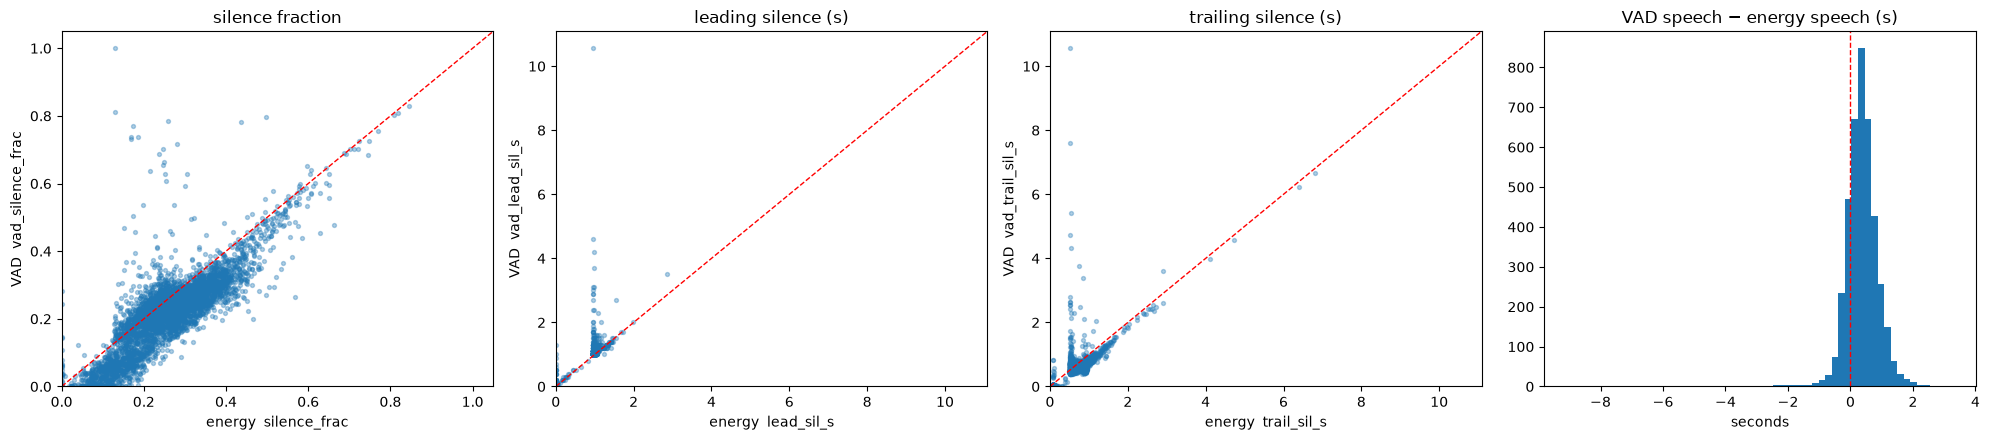

In [24]:
fig, ax = plt.subplots(1, 4, figsize=(20, 4.5))

for a, (e, v, t) in zip(ax, [
    ("silence_frac", "vad_silence_frac", "silence fraction"),
    ("lead_sil_s",   "vad_lead_sil_s",   "leading silence (s)"),
    ("trail_sil_s",  "vad_trail_sil_s",  "trailing silence (s)"),
]):
    s = cmp[[e, v]].dropna()
    a.scatter(s[e], s[v], s=8, alpha=.35)
    lim = max(s[e].max(), s[v].max()) * 1.05
    a.plot([0, lim], [0, lim], "r--", lw=1)
    a.set_xlim(0, lim); a.set_ylim(0, lim)
    a.set_xlabel(f"energy  {e}"); a.set_ylabel(f"VAD  {v}"); a.set_title(t)

energy_speech = cmp.duration * (1 - cmp.silence_frac)
ax[3].hist((cmp.vad_speech_s - energy_speech).dropna(), bins=60)
ax[3].axvline(0, color="r", ls="--", lw=1)
ax[3].set_title("VAD speech − energy speech (s)")
ax[3].set_xlabel("seconds")

plt.tight_layout(); plt.show()

### 6.4 Disagreement flags and audition

| Flag | Condition | Interpretation |
|---|---|---|
| `energy_missed_noise` | VAD says silent, energy said voiced | Background noise above threshold |
| `energy_over_trimmed` | VAD says voiced, energy said silent | Quiet speech below threshold |
| `vad_no_speech` | VAD finds no speech at all | Strong candidate for an empty/noise-only clip |
| `very_fragmented` | many separate speech segments | Long internal pauses or merged utterances |
| `vad_speech_too_short` | under 1 s of speech total | Too little content for a 30 s encoder window |

**Listen to these before changing any threshold** — the numbers tell you the two methods
disagree, but only the audio tells you which one is right.

In [25]:
vflags = pd.DataFrame({
    "energy_missed_noise":  (cmp.d_silence >  0.15),
    "energy_over_trimmed":  (cmp.d_silence < -0.15),
    "lead_disagree_0.5s":   (cmp.d_lead.abs()  > 0.5),
    "trail_disagree_0.5s":  (cmp.d_trail.abs() > 0.5),
    "vad_no_speech":        (cmp.vad_speech_s == 0),
    "vad_speech_too_short": (cmp.vad_speech_s < 1.0),
    "very_fragmented":      (cmp.vad_n_segments > 8),
})
vflags["split"] = cmp.split

display(vflags.drop(columns="split").sum().to_frame("n_clips"))
display(vflags.groupby("split").sum())

cmp["disagreement"] = (cmp.d_silence.abs() + cmp.d_lead.abs()/10 + cmp.d_trail.abs()/10)

print("\nMost contested clips — listen before trusting either method:")
display(cmp.sort_values("disagreement", ascending=False)
           .head(15)[["split", "duration", "rms_dbfs",
                      "silence_frac", "vad_silence_frac", "d_silence",
                      "lead_sil_s", "vad_lead_sil_s",
                      "vad_n_segments", "disagreement"]].round(3))

,n_clips
energy_missed_noise,41
energy_over_trimmed,66
lead_disagree_0.5s,41
trail_disagree_0.5s,45
vad_no_speech,1
vad_speech_too_short,1
very_fragmented,4


,energy_missed_noise,energy_over_trimmed,lead_disagree_0.5s,trail_disagree_0.5s,vad_no_speech,vad_speech_too_short,very_fragmented
split,,,,,,,
test,10,10,6,9,0,0,1
train,25,44,28,30,0,0,2
validation,6,12,7,6,1,1,1



Most contested clips — listen before trusting either method:


,split,duration,rms_dbfs,silence_frac,vad_silence_frac,d_silence,lead_sil_s,vad_lead_sil_s,vad_n_segments,disagreement
idx,,,,,,,,,,
3306,validation,10.56,-13.168,0.131,1.000,0.869,0.960,10.56,0,2.834
3322,validation,10.59,-23.083,0.131,0.811,0.680,0.960,1.00,1,1.392
60,train,8.31,-27.703,0.174,0.771,0.597,0.992,1.00,1,1.085
3780,test,8.22,-18.367,0.169,0.732,0.564,0.960,1.00,2,0.989
734,train,8.43,-19.649,0.168,0.739,0.571,0.960,4.60,3,0.975
1877,train,6.96,-28.583,0.259,0.784,0.525,0.960,1.00,2,0.830
3718,test,6.09,-28.078,0.238,0.688,0.450,0.992,3.10,1,0.718
2250,train,7.62,-25.438,0.186,0.738,0.552,0.960,1.30,2,0.706
3663,test,5.67,-22.512,0.250,0.665,0.415,0.960,3.10,1,0.644


In [26]:
for i in cmp.sort_values("disagreement", ascending=False).index[:6]:
    r = cmp.loc[i]
    print(f"[{i}] {r.split} | {r.duration:.2f}s | RMS {r.rms_dbfs:.1f} dBFS")
    print(f"    energy: silence {r.silence_frac:.2f}  lead {r.lead_sil_s:.2f}s  trail {r.trail_sil_s:.2f}s")
    print(f"    VAD   : silence {r.vad_silence_frac:.2f}  lead {r.vad_lead_sil_s:.2f}s  "
          f"trail {r.vad_trail_sil_s:.2f}s  segments {int(r.vad_n_segments)}")
    play(i)
    print("-" * 80)

[3306] validation | 10.56s | RMS -13.2 dBFS
    energy: silence 0.13  lead 0.96s  trail 0.51s
    VAD   : silence 1.00  lead 10.56s  trail 10.56s  segments 0
[3306] validation | 16000 Hz | 10.56s
හිමි නොවෙනා බව දැනුනත් වෙන් වීමක් නොමැතී.


--------------------------------------------------------------------------------
[3322] validation | 10.59s | RMS -23.1 dBFS
    energy: silence 0.13  lead 0.96s  trail 0.51s
    VAD   : silence 0.81  lead 1.00s  trail 7.59s  segments 1
[3322] validation | 16000 Hz | 10.59s
එහෙම නැත්නම් සබරගමු කලාපය කියලා


--------------------------------------------------------------------------------
[60] train | 8.31s | RMS -27.7 dBFS
    energy: silence 0.17  lead 0.99s  trail 0.53s
    VAD   : silence 0.77  lead 1.00s  trail 5.41s  segments 1
[60] train | 16000 Hz | 8.31s
ආණ්ඩුවටත් වදිනවා ජෙහාන්


--------------------------------------------------------------------------------
[3780] test | 8.22s | RMS -18.4 dBFS
    energy: silence 0.17  lead 0.96s  trail 0.51s
    VAD   : silence 0.73  lead 1.00s  trail 4.72s  segments 2
[3780] test | 16000 Hz | 8.22s
දුවලා යං set  එකට


--------------------------------------------------------------------------------
[734] train | 8.43s | RMS -19.6 dBFS
    energy: silence 0.17  lead 0.96s  trail 0.53s
    VAD   : silence 0.74  lead 4.60s  trail 0.93s  segments 3
[734] train | 16000 Hz | 8.43s
මේ travel with chathura


--------------------------------------------------------------------------------
[1877] train | 6.96s | RMS -28.6 dBFS
    energy: silence 0.26  lead 0.96s  trail 0.75s
    VAD   : silence 0.78  lead 1.00s  trail 3.76s  segments 2
[1877] train | 16000 Hz | 6.96s
මං හරි ආදරෙන් ඉමි නුබ ලග


--------------------------------------------------------------------------------


In [27]:
# Clips Silero VAD found no speech in at all (vad_no_speech), or under 1s of speech
# (vad_speech_too_short) — listen to confirm they're genuinely silent/noise rather than
# missed quiet speech.
silent_clips = cmp[vflags["vad_no_speech"] | vflags["vad_speech_too_short"]]
print(f"VAD-silent clips: {len(silent_clips)}")

for i in silent_clips.index:
    r = cmp.loc[i]
    print(f"[{i}] {r.split} | {r.duration:.2f}s | RMS {r.rms_dbfs:.1f} dBFS | "
          f"vad_speech_s={r.vad_speech_s:.2f}s | energy silence_frac={r.silence_frac:.2f}")
    print(df.at[i, "text"][:300])
    play(i)
    print("-" * 80)

VAD-silent clips: 1
[3306] validation | 10.56s | RMS -13.2 dBFS | vad_speech_s=0.00s | energy silence_frac=0.13
හිමි නොවෙනා බව දැනුනත් වෙන් වීමක් නොමැතී.
[3306] validation | 16000 Hz | 10.56s
හිමි නොවෙනා බව දැනුනත් වෙන් වීමක් නොමැතී.


--------------------------------------------------------------------------------


---

## 7. What this tells us, and what comes next

1. **Format** — confirm every clip is 16 kHz mono; if so, no resampling step is needed.
2. **Duration** — check for clips approaching or exceeding the 30 s window; filter or truncate-flag
   those explicitly.
3. **Transcript integrity** — use the chars-per-second, empty-text, duplicate, and language checks
   above as a shortlist to fix or drop. Fix where the audio is intact.
4. **Silence and level** — the energy-versus-VAD comparison decides whether a trimming step is
   needed, and which measurement should drive it.

Before training: verify no transcript exceeds Whisper's 448-token decoder limit after
tokenisation, and evaluate un-fine-tuned `whisper-small` on a held-out slice to get a baseline WER.

---

## 8. Drop confirmed bad rows

Removing the rows identified above as unusable:

- **258, 1807, 3555** — duplicate "Audio not suitable for transcription" placeholder transcripts (no real label).
- **2095** — duplicate audio/transcript pair (keeping 1497, the other half of the duplicate group).
- **3306** — Silero VAD found zero speech in the clip (`vad_speech_s == 0`), the sole `vad_no_speech` case.

In [28]:
DROP_IDS = [258, 1807, 3555, 2095, 3306]

print(f"Before: {df.shape}")
df_clean = df.drop(index=DROP_IDS)
print(f"After:  {df_clean.shape}")
print(f"Dropped {len(df) - len(df_clean)} rows: {DROP_IDS}")

Before: (4037, 14)
After:  (4032, 14)
Dropped 5 rows: [258, 1807, 3555, 2095, 3306]
